<a href="https://colab.research.google.com/github/fabel134/yeast_mapping_in_metagenomes/blob/main/260504_Copia_de_figure1C_colab_multi_reference_refs_separados_DOCUMENTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Figura tipo 1C multi-referencia para muestras metagenómicas de *Saccharomyces*

Este notebook analiza las tablas `*.10kb_similarity.csv` generadas por tu pipeline de ventanas de 10 kb.

La lógica general es:

```text
BAM filtrado + VCF filtrado
↓
ventanas de 10 kb
↓
N_sites, SNPs_d, divergence, similarity
↓
figuras y resúmenes por referencia/muestra
```

La métrica `similarity_N_over_dplus1` está inspirada en la Figura 1C del artículo *High-Resolution Mapping of Complex Traits with a Four-Parent Advanced Intercross Yeast Population*:

```text
similarity = N / (d + 1)
```

donde:

- `N` = número de sitios comparables en una ventana
- `d` = número de diferencias de un solo nucleótido

En tu adaptación:

- cada muestra metagenómica se compara contra varias referencias
- cada referencia se analiza por separado
- los resultados se resumen por ventana, por cromosoma, por muestra y por referencia

## 1. Instalar librerías

Este notebook usa:

- `pandas` para leer y resumir tablas
- `matplotlib` para hacer figuras

En Colab normalmente ya están instaladas, pero esta celda asegura que estén disponibles.

In [70]:
!pip -q install pandas matplotlib

## 2. Conectar Google Drive

Colab no puede leer directamente los archivos de tu cluster.  
Por eso, los resultados de `results_by_ref/` deben estar copiados a Google Drive.

Estructura esperada:

```text
MyDrive/yeast/results_by_ref/
├── AAR/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
├── ADE/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
└── ...
```

In [71]:
from google.colab import drive
drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted at /content/drive


In [72]:
ls -lh drive/MyDrive/yeast/

total 288K
drwx------ 2 root root 4.0K Apr 21 06:02 1C/
drwx------ 2 root root 4.0K Apr 23 21:20 figures_1C_like/
drwx------ 2 root root 4.0K May  5 02:18 figures_1C_multi_ref/
drwx------ 2 root root 4.0K Apr 20 23:25 heatmaps_por_muestra/
drwx------ 2 root root 4.0K May  6 18:38 results_by_ref/
drwx------ 2 root root 4.0K May  7 02:11 results_by_ref_500/
drwx------ 2 root root 4.0K May  6 18:38 results_by_ref_controles/
-rw------- 1 root root 260K Apr 17 06:28 tabla_final.tsv


In [73]:
ls -lh drive/MyDrive/yeast/results_by_ref_500


total 20K
drwx------ 2 root root 4.0K May  7 02:11 AAR/
drwx------ 2 root root 4.0K May  7 02:11 sake/
drwx------ 2 root root 4.0K May  7 02:11 scer/
drwx------ 2 root root 4.0K May  7 02:11 SGD_2010/
drwx------ 2 root root 4.0K May  7 02:11 ZP568s1/


## 3. Configuración general

Edita estas rutas si tus resultados están en otra carpeta.

Parámetros importantes:

- `RESULTS_ROOT`: carpeta principal con resultados separados por referencia
- `OUTPUT_DIR`: carpeta donde se guardarán figuras y tablas resumen
- `MIN_N_SITES`: mínimo de sitios comparables por ventana
- `MAX_SAMPLES_TO_PLOT`: limita cuántas muestras se grafican para evitar figuras saturadas

In [74]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt

# Carpeta con resultados por referencia
#RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref_1'
#RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref'
#RESULTS_ROOT_controles = '/content/drive/MyDrive/yeast/results_by_ref_controles'

RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref_500'

# Carpeta de salida para figuras y tablas resumen
#OUTPUT_DIR = '/content/drive/MyDrive/yeast/results_by_ref_1'
OUTPUT_DIR = '/content/drive/MyDrive/yeast/results_by_ref'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filtro mínimo de sitios comparables por ventana
MIN_N_SITES = 0

# Si tienes muchas muestras, puedes limitar el número graficado.
# Usa None para graficar todas.
MAX_SAMPLES_TO_PLOT = None

print('RESULTS_ROOT:', RESULTS_ROOT)
#print('RESULTS_ROOT_controles:', RESULTS_ROOT_controles)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('MIN_N_SITES:', MIN_N_SITES)
print('MAX_SAMPLES_TO_PLOT:', MAX_SAMPLES_TO_PLOT)

RESULTS_ROOT: /content/drive/MyDrive/yeast/results_by_ref_500
OUTPUT_DIR: /content/drive/MyDrive/yeast/results_by_ref
MIN_N_SITES: 0
MAX_SAMPLES_TO_PLOT: None


## 4. Detectar referencias disponibles

Cada subcarpeta dentro de `RESULTS_ROOT` se interpreta como una referencia.

Ejemplo:

```text
results_by_ref/AAR/
results_by_ref/ADE/
results_by_ref/SGD_2010/
```

El nombre de la carpeta se usa como nombre de referencia.

In [75]:
ref_dirs = sorted([
    d for d in glob.glob(os.path.join(RESULTS_ROOT, '*'))
    if os.path.isdir(d)
])

references = [os.path.basename(d) for d in ref_dirs]

print(f'Referencias encontradas: {len(references)}')
print(references)

Referencias encontradas: 5
['AAR', 'SGD_2010', 'ZP568s1', 'sake', 'scer']


In [76]:
ls $RESULTS_ROOT/SGD_2010/windows_500

40_Melli.500kb_similarity.csv
41_Melli.500kb_similarity.csv
46_Melli.500kb_similarity.csv
47_Melli.500kb_similarity.csv
51_Scapto.500kb_similarity.csv
ERR2212269.500kb_similarity.csv
ERR4757811.500kb_similarity.csv
ERR4757824.500kb_similarity.csv
Scerevisiae_0.001pct_NO.500kb_similarity.csv
Scerevisiae_0.1pct_NO.500kb_similarity.csv
Scerevisiae_10pct_NO.500kb_similarity.csv
Scerevisiae_mutated_0.001pct.500kb_similarity.csv
Scerevisiae_mutated_0.1pct.500kb_similarity.csv
Scerevisiae_mutated_10pct.500kb_similarity.csv
Scerevisiae_window_mutated_0.001pct.500kb_similarity.csv
Scerevisiae_window_mutated_0.1pct.500kb_similarity.csv
Scerevisiae_window_mutated_10pct.500kb_similarity.csv
SRR10997050.500kb_similarity.csv
SRR25395502.500kb_similarity.csv
SRR25395505.500kb_similarity.csv
SRR25395509.500kb_similarity.csv
SRR27931737_Es.500kb_similarity.csv
SRR27931754_Es.500kb_similarity.csv
SRR27931755_Es.500kb_similarity.csv
SRR27931758_Es.500kb_similarity.csv
SRR27931764_Es.500kb_similarity.csv


## 5. Funciones auxiliares

Estas funciones hacen tres cosas:

1. ordenar cromosomas correctamente (`chr1`, `chr2`, ..., `chr16`)
2. cargar todas las tablas de una referencia
3. preparar los datos para análisis y figuras

Columnas esperadas en cada CSV:

- `sample`
- `chrom`
- `start`
- `end`
- `N_sites`
- `SNPs_d`
- `divergence_d_over_N`
- `similarity_N_over_dplus1`

Significado:

- `N_sites`: posiciones comparables dentro de una ventana
- `SNPs_d`: SNPs detectados en esa ventana
- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: sitios comparables por diferencia, inspirado en la Figura 1C

natural_chr_key(chrom): Esta función se encarga de ordenar los cromosomas.

In [79]:

def natural_chr_key(chrom):
    # Ordena cromosomas de forma biológica.
    # Funciona con nombres como chr1, chr10, chr1_AAR, chr12_ADE, chrI, chrII.
    chrom = str(chrom)

    # Caso numérico: chr1, chr2, chr10, chr1_AAR
    match = re.search(r'chr(\d+)', chrom, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Caso romano: chrI, chrII, chrXVI
    c = chrom.replace('chr', '').replace('Chr', '').split('_')[0]
    roman_map = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4,
        'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8,
        'IX': 9, 'X': 10, 'XI': 11, 'XII': 12,
        'XIII': 13, 'XIV': 14, 'XV': 15, 'XVI': 16
    }

    if c in roman_map:
        return roman_map[c]

    # Si no reconoce el formato, lo manda al final
    return 999

load_reference_tables(ref_name): Esta función es responsable de cargar y preprocesar los datos de similitud de ventanas de 10kb para una referencia específica.

In [80]:
def load_reference_tables(ref_name):
    # Carga todos los CSV de ventanas de 10 kb para una referencia.
    #
    # Busca archivos en:
    # RESULTS_ROOT/ref_name/windows_10kb/*.10kb_similarity.csv
    #
    #

    #input_dir = os.path.join(RESULTS_ROOT, ref_name, 'windows_10kb')
    input_dir = os.path.join(RESULTS_ROOT, ref_name, 'windows_500')
    #input_dir_cont = os.path.join(RESULTS_ROOT_controles, ref_name, 'windows_10kb')
    input_dir_cont = os.path.join(RESULTS_ROOT_controles, ref_name, 'windows_500')

    # Get files from the main results directory
    #files_main = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))
    files_main = sorted(glob.glob(os.path.join(input_dir, '*.500kb_similarity.csv')))
    # Get files from the controls results directory
    #files_cont = sorted(glob.glob(os.path.join(input_dir_cont, '*.10kb_similarity.csv')))

    # Combine all files
    #files = files_main + files_cont
    files = files_main

    if not files:
        raise FileNotFoundError(f'No CSVs found in {input_dir} or {input_dir_cont}')

    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Si el archivo no trae columna sample, la inferimos desde el nombre
        if 'sample' not in df.columns:
            #df['sample'] = os.path.basename(f).replace('.10kb_similarity.csv', '')
            df['sample'] = os.path.basename(f).replace('.500kb_similarity.csv', '')

        # Agregamos la referencia para comparar después
        df['reference'] = ref_name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Convertir columnas numéricas
    numeric_cols = [
        'start', 'end', 'N_sites', 'SNPs_d',
        'divergence_d_over_N', 'similarity_N_over_dplus1'
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    # Filtrar ventanas con poca información
    out = out[out['N_sites'] >= MIN_N_SITES].copy()

    # Posición inicial en megabases para que el eje X sea más legible
    out['start_mb'] = out['start'] / 1e6

    return out



aggregate_metrics_across_all_chromosomes(references): Esta función carga los datos de similitud/divergencia para todas las referencias y todos los cromosomas, y agrega las métricas `N_sites` y `SNPs_d` por `sample` y `reference`. Luego calcula `divergence_d_over_N` y `similarity_N_over_dplus1` a nivel global para cada combinación `sample`/`reference`.

In [81]:
def aggregate_metrics_across_all_chromosomes(references):
    all_aggregated_data = []

    print("Agregando métricas para todas las referencias y cromosomas...")
    for ref_name in references:
        try:
            df_ref = load_reference_tables(ref_name)
            # Agrupar por muestra y sumar N_sites y SNPs_d para todos los cromosomas
            aggregated_df = df_ref.groupby('sample').agg(
                total_N_sites=('N_sites', 'sum'),
                total_SNPs_d=('SNPs_d', 'sum'),
                reference=('reference', 'first') # Mantener el nombre de la referencia
            ).reset_index()

            # Recalcular las métricas a nivel agregado
            aggregated_df['overall_divergence_d_over_N'] = aggregated_df['total_SNPs_d'] / aggregated_df['total_N_sites']
            aggregated_df['overall_similarity_N_over_dplus1'] = aggregated_df['total_N_sites'] / (aggregated_df['total_SNPs_d'] + 1)

            all_aggregated_data.append(aggregated_df)
            print(f"  - Datos agregados para la referencia: {ref_name}")

        except FileNotFoundError:
            print(f"  - Advertencia: No se encontraron archivos para la referencia {ref_name}. Saltando...")
        except Exception as e:
            print(f"  - Error al procesar la referencia {ref_name}: {e}")

    if not all_aggregated_data:
        print("No se pudieron agregar datos para ninguna referencia.")
        return pd.DataFrame()

    final_df = pd.concat(all_aggregated_data, ignore_index=True)
    return final_df

## 6. Verificación rápida de datos

Esta celda revisa cuántos archivos de ventanas existen por referencia.

Si una referencia aparece con `0` archivos, significa que:

- no corriste `02_run_similarity_tables_multi_ref.sh` para esa referencia
- o no copiaste los resultados a Google Drive
- o la ruta `RESULTS_ROOT` está mal

In [82]:
file_counts = []

for ref in references:
    #input_dir = os.path.join(RESULTS_ROOT, ref, 'windows_10kb')
    input_dir = os.path.join(RESULTS_ROOT, ref, 'windows_500')
    #input_dir_cont = os.path.join(RESULTS_ROOT_controles, ref, 'windows_10kb')

    # Get files from the main results directory
    #files_main = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))
    files_main = sorted(glob.glob(os.path.join(input_dir, '*.500kb_similarity.csv')))
    # Get files from the controls results directory
    #files_cont = sorted(glob.glob(os.path.join(input_dir_cont, '*.10kb_similarity.csv')))
    #files_cont = sorted(glob.glob(os.path.join(input_dir_cont, '*.500kb_similarity.csv')))

    # Combine all files
    #files = files_main + files_cont
    files = files_main

    #files = glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv'))
    file_counts.append({'reference': ref, 'n_csv_files': len(files)})

file_counts_df = pd.DataFrame(file_counts)
file_counts_df

,reference,n_csv_files
0,AAR,19
1,SGD_2010,26
2,ZP568s1,19
3,sake,19
4,scer,19


## 7. Graficar una figura tipo 1C por referencia

Esta sección genera **una figura por referencia**.

En cada figura:

- cada panel = un cromosoma
- cada línea = una muestra
- eje X = posición genómica en Mb
- eje Y = métrica elegida

Métricas disponibles:

- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: métrica inspirada en el paper, `N/(d+1)`

Recomendación:

- usa `divergence_d_over_N` para interpretación
- usa `similarity_N_over_dplus1` para una visualización más parecida a la Figura 1C

mapear cada sample → color fijo. Para los reads simulados y que sirven como controles

In [83]:
SAMPLE_COLORS = {
    #"Scerevisiae_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_mutated_0.1pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

    #"Scerevisiae_0.001pct_NO": "#C33B80",
    #"Scerevisiae_0.1pct_NO": "#008F00",
    #"Scerevisiae_10pct_NO": "#3EAEC7",

    #"Scerevisiae_window_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_window_mutated_0.1pct": "#008F00",
    #"Scerevisiae_window_mutated_10pct": "#3EAEC7",

    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

}
#METRIC = "divergence_d_over_N"
METRIC = "similarity_N_over_dplus1"

# Cambiar CHROM_TARGET para que coincida con los nombres de cromosomas en los datos (e.g., chrN_REF_NAME)
# Si quieres graficar para un cromosoma específico, asegúrate que su nombre exista en los datos.
# Por ejemplo, para la referencia 'scer', los cromosomas pueden ser 'chr1_scer', 'chr2_scer', etc.
CHROM_TARGET = "chr2"



In [84]:
df_aar = load_reference_tables("SGD_2010")
df_aar[df_aar['chrom'].str.contains('chr2') & (df_aar['start'] >= 1) & (df_aar['start'] <= 100000)]

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
461,40_Melli,chr2,1,500,0,0,NaN,NaN,SGD_2010,0.000001
462,40_Melli,chr2,501,1000,0,0,NaN,NaN,SGD_2010,0.000501
463,40_Melli,chr2,1001,1500,0,0,NaN,NaN,SGD_2010,0.001001
464,40_Melli,chr2,1501,2000,0,0,NaN,NaN,SGD_2010,0.001501
465,40_Melli,chr2,2001,2500,0,0,NaN,NaN,SGD_2010,0.002001
...,...,...,...,...,...,...,...,...,...,...
609031,Scerevisiae_window_mutated_10pct,chr2,97501,98000,500,0,0.0,500.0,SGD_2010,0.097501
609032,Scerevisiae_window_mutated_10pct,chr2,98001,98500,500,0,0.0,500.0,SGD_2010,0.098001
609033,Scerevisiae_window_mutated_10pct,chr2,98501,99000,500,0,0.0,500.0,SGD_2010,0.098501
609034,Scerevisiae_window_mutated_10pct,chr2,99001,99500,500,0,0.0,500.0,SGD_2010,0.099001


In [85]:
df_chr2_aar = df_aar[df_aar['chrom'] == 'chr2']
df_chr2_aar
snps_by_sample = df_chr2_aar.groupby('sample')['SNPs_d'].sum()
print("Total SNPs for chr2_AAR by sample:\n", snps_by_sample)


Total SNPs for chr2_AAR by sample:
 sample
40_Melli                                  0
41_Melli                                  0
46_Melli                                  0
47_Melli                                  0
51_Scapto                                 0
ERR2212269                                1
ERR4757811                                1
ERR4757824                             1994
SRR10997050                             107
SRR25395502                               0
SRR25395505                              14
SRR25395509                               3
SRR27931737_Es                            0
SRR27931754_Es                            9
SRR27931755_Es                            6
SRR27931758_Es                           34
SRR27931764_Es                            0
Scerevisiae_0.001pct_NO                1272
Scerevisiae_0.1pct_NO                  1281
Scerevisiae_10pct_NO                   1129
Scerevisiae_mutated_0.001pct           1272
Scerevisiae_mutated_0.1pct       

In [86]:
dfs_chr2_by_reference = {}

for ref_name in references:
    print(f"Cargando y filtrando datos para la referencia: {ref_name}")
    try:
        df_ref = load_reference_tables(ref_name)

        # Check for 'chr2' and 'chr2_REF_NAME'
        chrom_options = ['chr2']
        if f'chr2_{ref_name}' in df_ref['chrom'].unique():
            chrom_options.append(f'chr2_{ref_name}')

        # Filter for chromosome 2 using any of the possible names
        df_chr2 = df_ref[df_ref['chrom'].isin(chrom_options)].copy()

        if not df_chr2.empty:
            dfs_chr2_by_reference[ref_name] = df_chr2
            print(f"  DataFrame para {ref_name} (cromosoma 2) creado con {len(df_chr2)} filas.")
        else:
            print(f"  No se encontraron datos para 'chr2' o 'chr2_{ref_name}' en la referencia {ref_name}.")

    except FileNotFoundError as e:
        print(f"  Advertencia: No se encontraron archivos para la referencia {ref_name}: {e}")
    except Exception as e:
        print(f"  Error procesando la referencia {ref_name}: {e}")

print("\n--- Resumen de DataFrames de cromosoma 2 creados ---")
for ref, df in dfs_chr2_by_reference.items():
    print(f"  Referencia '{ref}': {len(df)} filas")

Cargando y filtrando datos para la referencia: AAR
  DataFrame para AAR (cromosoma 2) creado con 30419 filas.
Cargando y filtrando datos para la referencia: SGD_2010
  DataFrame para SGD_2010 (cromosoma 2) creado con 42302 filas.
Cargando y filtrando datos para la referencia: ZP568s1
  DataFrame para ZP568s1 (cromosoma 2) creado con 30514 filas.
Cargando y filtrando datos para la referencia: sake
  DataFrame para sake (cromosoma 2) creado con 30020 filas.
Cargando y filtrando datos para la referencia: scer
  DataFrame para scer (cromosoma 2) creado con 30913 filas.

--- Resumen de DataFrames de cromosoma 2 creados ---
  Referencia 'AAR': 30419 filas
  Referencia 'SGD_2010': 42302 filas
  Referencia 'ZP568s1': 30514 filas
  Referencia 'sake': 30020 filas
  Referencia 'scer': 30913 filas


In [87]:
df_chr2.head()

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
461,40_Melli,chr2_scer,1,500,0,0,NaN,NaN,scer,0.000001
462,40_Melli,chr2_scer,501,1000,0,0,NaN,NaN,scer,0.000501
463,40_Melli,chr2_scer,1001,1500,0,0,NaN,NaN,scer,0.001001
464,40_Melli,chr2_scer,1501,2000,0,0,NaN,NaN,scer,0.001501
465,40_Melli,chr2_scer,2001,2500,0,0,NaN,NaN,scer,0.002001


In [88]:
print(df_chr2.shape)

(30913, 10)


In [89]:
print("--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---")
all_references_snps_chr2 = {}

for ref_name, df_chr2 in dfs_chr2_by_reference.items():
    if not df_chr2.empty:
        snps_by_sample = df_chr2.groupby('sample')['SNPs_d'].sum()
        all_references_snps_chr2[ref_name] = snps_by_sample
        print(f"\nReferencia: {ref_name}")
        print(snps_by_sample)
    else:
        print(f"\nReferencia: {ref_name} - No hay datos para el cromosoma 2.")

print("----------------------------------------------------------------")

--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---

Referencia: AAR
sample
40_Melli                               0
41_Melli                               0
46_Melli                               0
47_Melli                               0
51_Scapto                              0
ERR2212269                             2
ERR4757811                             1
ERR4757824                          1965
SRR10997050                          108
SRR25395502                            0
SRR25395505                           11
SRR25395509                            4
SRR27931737_Es                         0
SRR27931754_Es                         3
SRR27931755_Es                         8
SRR27931758_Es                        21
SRR27931764_Es                         0
Scerevisiae_10pct_NO                4562
Scerevisiae_window_mutated_10pct    4452
Name: SNPs_d, dtype: int64

Referencia: SGD_2010
sample
40_Melli                                  0
41_Melli               

In [60]:
# Concatenar *todos* los DataFrames de dfs_chr2_by_reference
df_combined_plot = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

In [61]:
print(df_combined_plot[
    (df_combined_plot['sample'] == 'Scerevisiae_10pct_NO') &
    (df_combined_plot['chrom'].str.contains('chr2')) &
    (df_combined_plot['reference'] == 'SGD_2010')
].head(10))

                     sample chrom  start     end  N_sites  SNPs_d  \
12666  Scerevisiae_10pct_NO  chr2      1   10000     7152       0   
12667  Scerevisiae_10pct_NO  chr2  10001   20000    10000       9   
12668  Scerevisiae_10pct_NO  chr2  20001   30000    10000       0   
12669  Scerevisiae_10pct_NO  chr2  30001   40000     8528     113   
12670  Scerevisiae_10pct_NO  chr2  40001   50000    10000      14   
12671  Scerevisiae_10pct_NO  chr2  50001   60000    10000       0   
12672  Scerevisiae_10pct_NO  chr2  60001   70000    10000       0   
12673  Scerevisiae_10pct_NO  chr2  70001   80000    10000       0   
12674  Scerevisiae_10pct_NO  chr2  80001   90000    10000      69   
12675  Scerevisiae_10pct_NO  chr2  90001  100000    10000       1   

       divergence_d_over_N  similarity_N_over_dplus1 reference  start_mb  
12666              0.00000               7152.000000  SGD_2010  0.000001  
12667              0.00090               1000.000000  SGD_2010  0.010001  
12668          

In [90]:
print("Valores únicos en la columna 'sample' de df_chr2:")
print(df_combined_plot['sample'].unique())

print("\nValores únicos en la columna 'reference' de df_chr2:")
print(df_combined_plot['reference'].unique())

Valores únicos en la columna 'sample' de df_chr2:
['40_Melli' '41_Melli' '46_Melli' '47_Melli' '51_Scapto' 'ERR2212269'
 'ERR4757811' 'ERR4757824' 'SRR10997050' 'SRR25395502' 'SRR25395505'
 'SRR25395509' 'SRR27931737_Es' 'SRR27931754_Es' 'SRR27931755_Es'
 'SRR27931758_Es' 'SRR27931764_Es' 'Scerevisiae_10pct_NO'
 'Scerevisiae_tworef_10pct' 'Scerevisiae_window_mutated_0.005_10pct'
 'Scerevisiae_window_mutated_0.9_10pct']

Valores únicos en la columna 'reference' de df_chr2:
['AAR' 'ADE' 'AEG' 'AGK' 'AHL' 'ATV' 'BLD_1a' 'L1374' 'SGD_2010' 'SK1'
 'SX2' 'W303' 'Y12' 'YPS128' 'ZP568s1' 'sake' 'scer']


### Ejemplo de uso de la función `plot_similarity_for_sample_and_reference`

Ahora puedes usar la función para graficar cualquier combinación de muestra y referencia. Simplemente cambia los valores de `chosen_sample` y `chosen_reference`.

In [91]:
def plot_similarity_for_sample_and_reference(sample_name, references_to_plot, metric='similarity_N_over_dplus1'):
    """
    Genera una gráfica de la métrica de similitud o divergencia para una muestra
    y una o varias referencias específicas en el cromosoma 2.

    Args:
        sample_name (str): El nombre de la muestra a graficar.
        references_to_plot (str or list): El nombre de la referencia o una lista de nombres de referencias a graficar.
        metric (str): La métrica a graficar ('similarity_N_over_dplus1' o 'divergence_d_over_N').
    """

    # Asegurarse de que `references_to_plot` sea una lista para facilitar el filtrado
    if isinstance(references_to_plot, str):
        references_to_plot = [references_to_plot]

    # Check if df_combined_plot exists. If not, inform the user.
    if 'df_combined_plot' not in globals():
        print("Error: `df_combined_plot` no está disponible. Asegúrate de haber ejecutado la celda que lo crea (anterior a la definición de esta función).")
        return

    # Filtrar el DataFrame combinado para la muestra y las referencias seleccionadas
    df_sample_ref_plot = df_combined_plot[
        (df_combined_plot['sample'] == sample_name) &
        (df_combined_plot['reference'].isin(references_to_plot))
    ].copy()

    if df_sample_ref_plot.empty:
        print(f"No se encontraron datos para la muestra '{sample_name}' con las referencias '{', '.join(references_to_plot)}'.")
        return

    plt.figure(figsize=(16, 8))
    sns.lineplot(
        x='start_mb',
        y=metric,
        data=df_sample_ref_plot,
        hue='reference', # Color para distinguir las diferentes referencias
        linewidth=1.5,
        markers=True,
        markersize=8
    )

    title_metric = 'Similarity' if metric == 'similarity_N_over_dplus1' else 'Divergence'

    if len(references_to_plot) == 1:
        title_refs = f"Reference: {references_to_plot[0]}"
    else:
        title_refs = f"All References"

    plt.title(f'{title_metric} ({metric}) for chr2 - Sample: {sample_name} vs {title_refs}', loc='left', fontsize=14)
    plt.xlabel('Genomic position (Mb)', fontsize=12)
    plt.ylabel(f'{title_metric} ({metric})', fontsize=12)
    #if metric == 'similarity_N_over_dplus1':
    if metric == 'divergence_d_over_N':
        plt.yscale('log')
    plt.grid(alpha=0.25)
    plt.legend(title='Reference', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

print("Función 'plot_similarity_for_sample_and_reference' modificada.")

Función 'plot_similarity_for_sample_and_reference' modificada.


In [93]:
unique_refer_in_combined_plot = df_combined_plot['reference'].unique().tolist()
print("Lista de referencias únicas en df_combined_plot:")
for refer in unique_refer_in_combined_plot:
    print(f"- {refer}")

Lista de referencias únicas en df_combined_plot:
- AAR
- ADE
- AEG
- AGK
- AHL
- ATV
- BLD_1a
- L1374
- SGD_2010
- SK1
- SX2
- W303
- Y12
- YPS128
- ZP568s1
- sake
- scer


In [65]:
# If you want to plot all unique samples:
#unique_samp_in_combined_plot = df_combined_plot['sample'].unique().tolist()

# If you want to plot a specific sample:
unique_samp_in_combined_plot = ['Scerevisiae_10pct_NO']

print("Lista de samples únicas en df_combined_plot (actualmente configurada):")
for samp in unique_samp_in_combined_plot:
    print(f"- {samp}")

Lista de samples únicas en df_combined_plot (actualmente configurada):
- Scerevisiae_10pct_NO


Generando gráfica para la referencia: Scerevisiae_10pct_NO


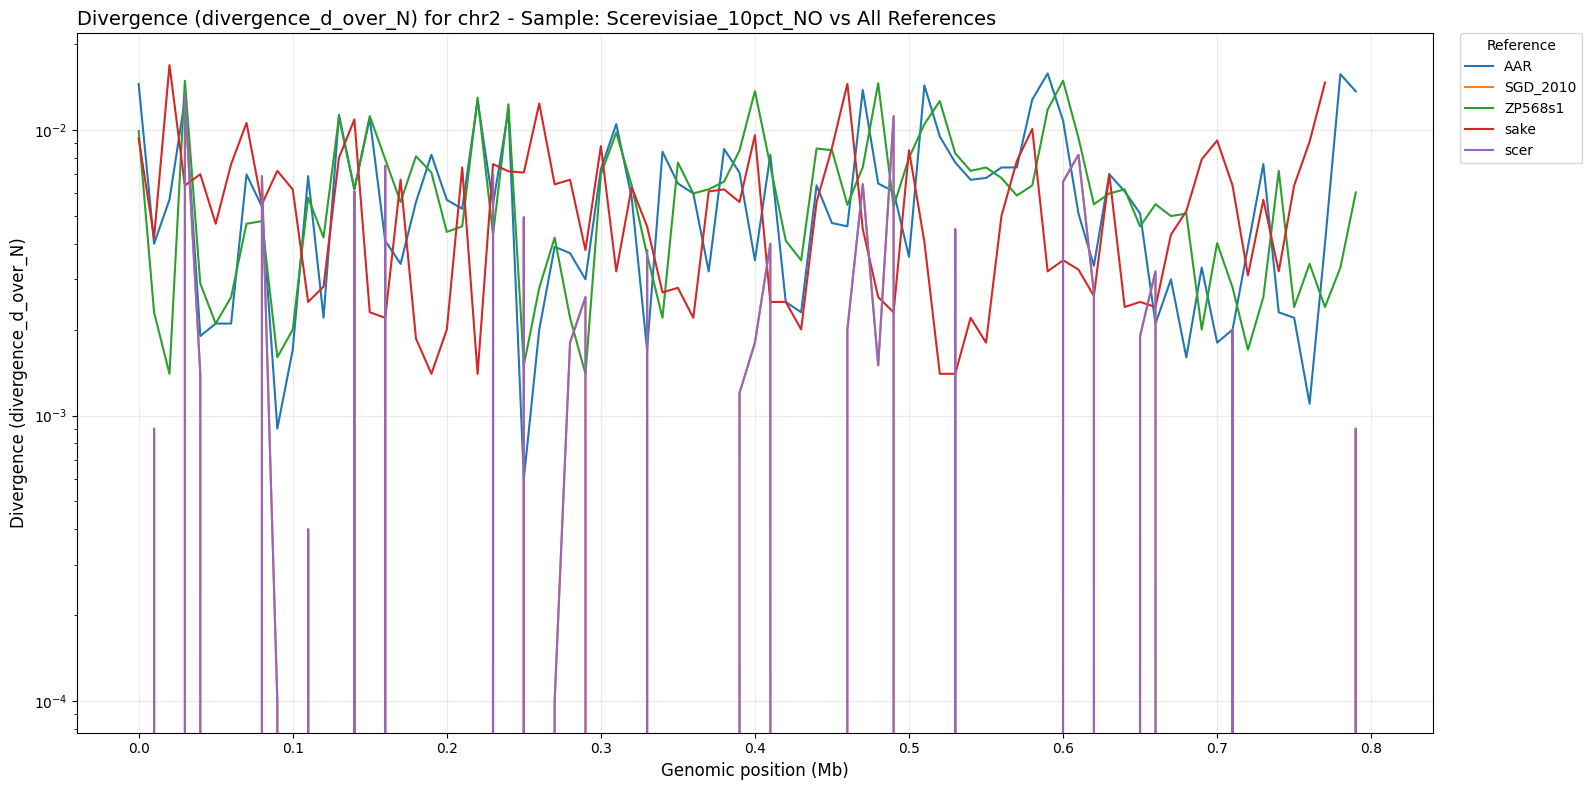

In [69]:
chosen_sample = unique_samp_in_combined_plot
chosen_references_list = unique_refer_in_combined_plot # Esto ya contiene todas tus referencias

for samp in chosen_sample:
    print(f"Generando gráfica para la referencia: {samp}")
    plot_similarity_for_sample_and_reference(samp, chosen_references_list, metric='divergence_d_over_N')


Generando gráfica para la referencia: Scerevisiae_10pct_NO


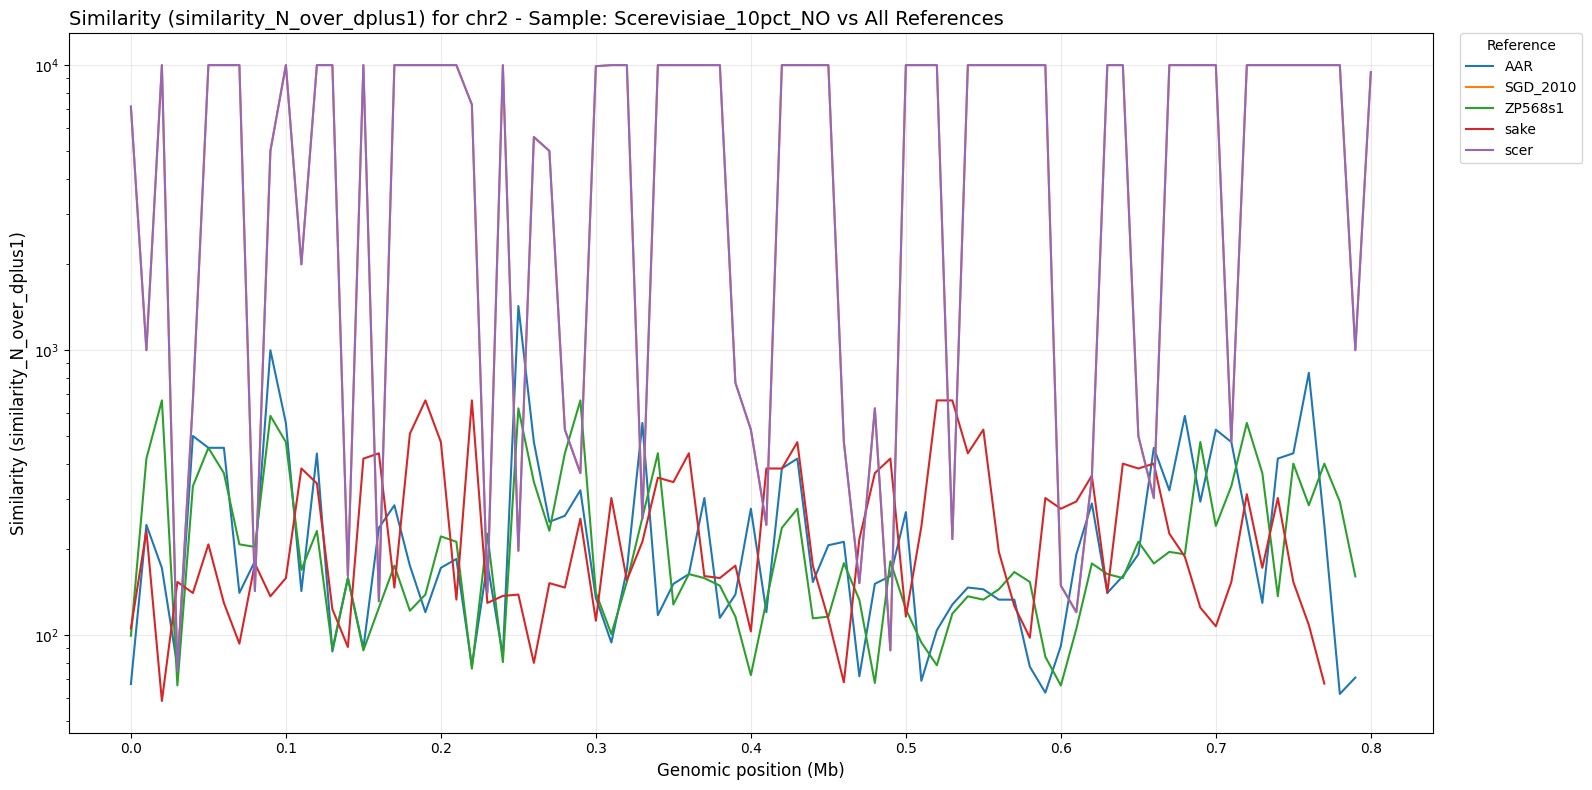

In [67]:
chosen_sample = unique_samp_in_combined_plot
chosen_references_list = unique_refer_in_combined_plot # Esto ya contiene todas tus referencias

for samp in chosen_sample:
    print(f"Generando gráfica para la referencia: {samp}")
    plot_similarity_for_sample_and_reference(samp, chosen_references_list, metric='similarity_N_over_dplus1')